# K Means Color Quantization

### Imports


In [1]:
import numpy as np

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import rawpy
import imageio

In [2]:
pip install rawpy

Note: you may need to restart the kernel to use updated packages.


### The Image

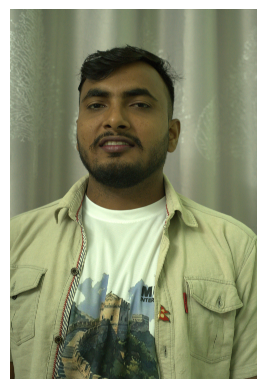

In [3]:


# Read the ARW file
with rawpy.imread("../DATA/my_images/DSC05024.ARW") as raw:
    image_as_array = raw.postprocess()

# Show the image
plt.imshow(image_as_array)
plt.axis('off')  # Optional: to hide axis
plt.show()

In [4]:
image_as_array # RGB CODES FOR EACH PIXEL

array([[[147, 165, 136],
        [147, 174, 134],
        [148, 180, 130],
        ...,
        [146, 127, 121],
        [148, 137, 109],
        [148, 144,  96]],

       [[146, 166, 141],
        [145, 176, 138],
        [150, 171, 137],
        ...,
        [150, 109, 125],
        [149, 131, 113],
        [146, 147, 101]],

       [[153, 156, 149],
        [149, 168, 146],
        [147, 172, 141],
        ...,
        [128, 130, 120],
        [133, 129, 116],
        [132, 135, 109]],

       ...,

       [[ 42,  41,  13],
        [ 53,  50,   9],
        [ 66,  45,  13],
        ...,
        [ 70,  62,  36],
        [ 92,  61,  33],
        [ 92,  62,  30]],

       [[ 48,  51,  20],
        [ 50,  42,  23],
        [ 51,  36,  24],
        ...,
        [ 68,  65,  34],
        [ 79,  60,  29],
        [ 80,  62,  21]],

       [[ 59,  41,  23],
        [ 48,  32,  26],
        [ 32,  33,  25],
        ...,
        [ 65,  71,  32],
        [ 63,  65,  28],
        [ 65,  61,  22]]

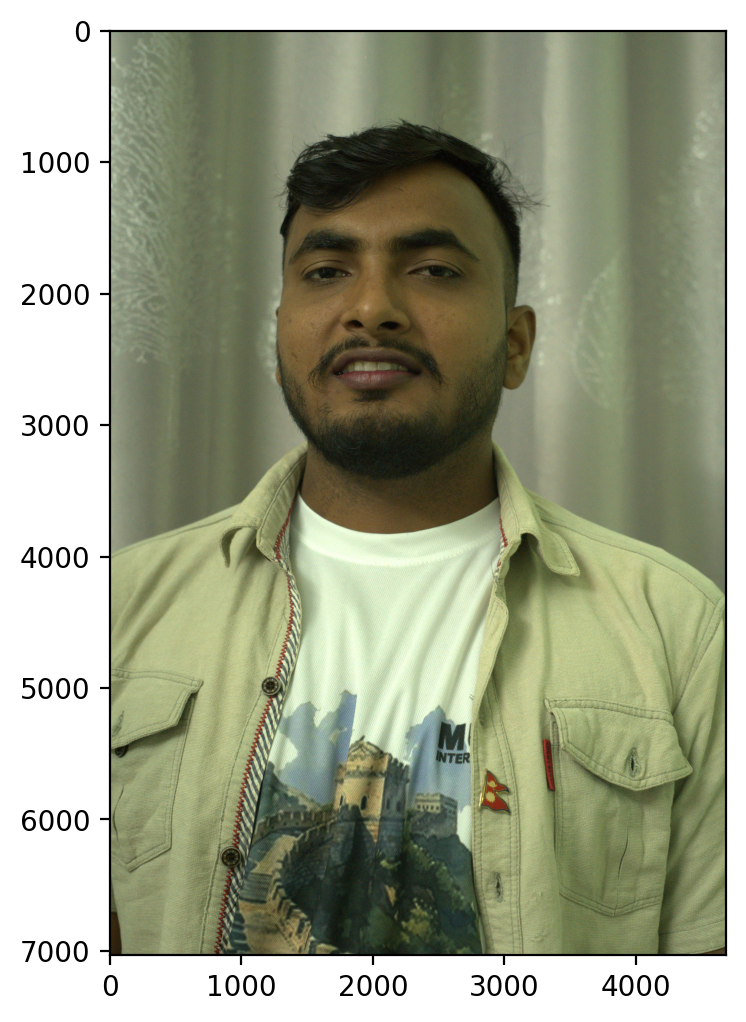

In [5]:
plt.figure(figsize=(6,6),dpi=200)
plt.imshow(image_as_array)

## Using Kmeans to Quantize Colors

Quantizing colors means we'll reduce the number of unique colors here to K unique colors. Let's try just 6 colors!

In [6]:
image_as_array.shape
# (h,w,3 color channels)

(7028, 4688, 3)

### Convert from 3d to 2d

Kmeans is designed to train on 2D data (data rows and feature columns), so we can reshape the above strip by using (h,w,c) ---> (h * w,c)

In [7]:
(h,w,c) = image_as_array.shape

In [8]:
image_as_array2d = image_as_array.reshape(h*w,c)

In [9]:
from sklearn.cluster import KMeans

In [20]:
model = KMeans(n_clusters=8)

In [21]:
model

KMeans()

In [22]:
labels = model.fit_predict(image_as_array2d)

In [23]:
labels

array([7, 7, 7, ..., 6, 6, 6], dtype=int32)

In [24]:
# THESE ARE THE 6 RGB COLOR CODES!
model.cluster_centers_

array([[ 97.47051458,  88.4608883 ,  55.13196094],
       [132.90300076, 141.16187486, 108.6159133 ],
       [223.54999601, 240.13209533, 205.13218591],
       [ 26.50515791,  32.08135781,  19.89912483],
       [109.11861286, 116.80975258,  86.39645688],
       [186.42238147, 193.65499457, 145.75717228],
       [ 61.08455576,  60.30972581,  38.32386827],
       [156.85753265, 164.68046509, 128.63233946]])

In [25]:
rgb_codes = model.cluster_centers_.round(0).astype(int)

In [26]:
rgb_codes

array([[ 97,  88,  55],
       [133, 141, 109],
       [224, 240, 205],
       [ 27,  32,  20],
       [109, 117,  86],
       [186, 194, 146],
       [ 61,  60,  38],
       [157, 165, 129]])

In [27]:
quantized_image = np.reshape(rgb_codes[labels], (h, w, c))

In [28]:
quantized_image

array([[[157, 165, 129],
        [157, 165, 129],
        [157, 165, 129],
        ...,
        [133, 141, 109],
        [133, 141, 109],
        [133, 141, 109]],

       [[157, 165, 129],
        [157, 165, 129],
        [157, 165, 129],
        ...,
        [133, 141, 109],
        [133, 141, 109],
        [133, 141, 109]],

       [[157, 165, 129],
        [157, 165, 129],
        [157, 165, 129],
        ...,
        [133, 141, 109],
        [133, 141, 109],
        [133, 141, 109]],

       ...,

       [[ 27,  32,  20],
        [ 61,  60,  38],
        [ 61,  60,  38],
        ...,
        [ 61,  60,  38],
        [ 61,  60,  38],
        [ 61,  60,  38]],

       [[ 61,  60,  38],
        [ 27,  32,  20],
        [ 27,  32,  20],
        ...,
        [ 61,  60,  38],
        [ 61,  60,  38],
        [ 61,  60,  38]],

       [[ 61,  60,  38],
        [ 27,  32,  20],
        [ 27,  32,  20],
        ...,
        [ 61,  60,  38],
        [ 61,  60,  38],
        [ 61,  60,  38]]

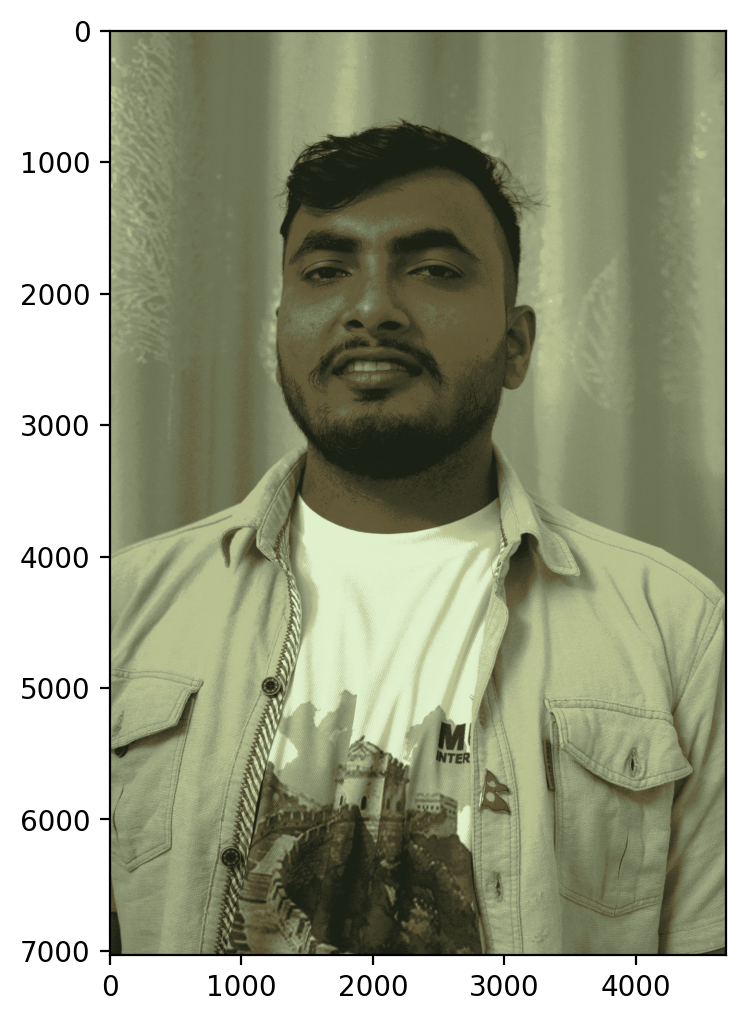

In [29]:
plt.figure(figsize=(6,6),dpi=200)
plt.imshow(quantized_image)